## Detrending z500 data

Detrend the data, then normalise the residual for GP.

Geopotential units: [m^2 s^-2] \
2m temp units: [K]

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
from pandas.plotting import register_matplotlib_converters

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.seasonal import seasonal_decompose

from GPyTorch.GPRs.utils import freq_spectrum

register_matplotlib_converters()
sns.set_style("darkgrid")

plt.rc("figure", figsize=(8, 6))
plt.rc("font", size=7)

In [3]:
# Data
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
data = z500.sel(time=slice('2000', '2017'))
point_worst = data['z'].sel(lat=50, lon=225, method='nearest')
point_best = data['z'].sel(lat=19.6875, lon=270, method='nearest')

## Global view of the data

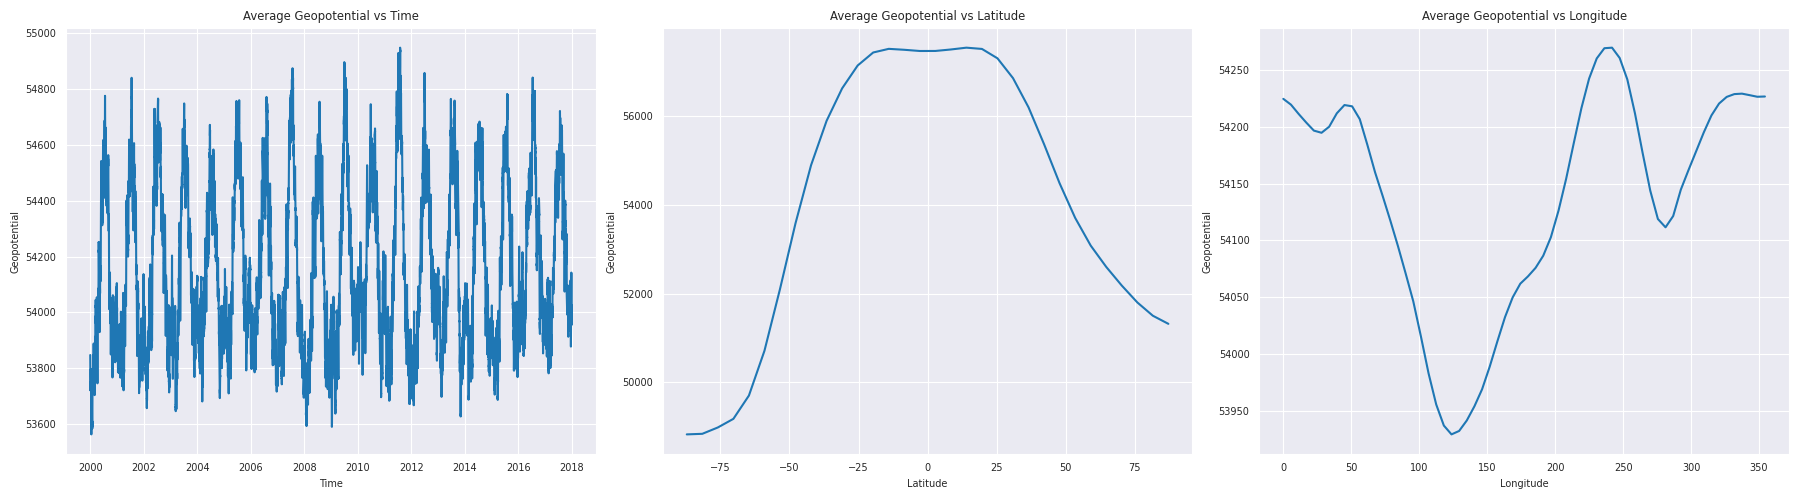

In [4]:
avg_time = data.z.mean(dim=["lat", "lon"])
avg_lat = data.z.mean(dim=["time", "lon"])
avg_lon = data.z.mean(dim=["time", "lat"])

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

avg_time.plot(ax=axs[0])
axs[0].set_title("Average Geopotential vs Time")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Geopotential")

avg_lat.plot(ax=axs[1])
axs[1].set_title("Average Geopotential vs Latitude")
axs[1].set_xlabel("Latitude")
axs[1].set_ylabel("Geopotential")

avg_lon.plot(ax=axs[2])
axs[2].set_title("Average Geopotential vs Longitude")
axs[2].set_xlabel("Longitude")
axs[2].set_ylabel("Geopotential")

plt.tight_layout()
plt.show()

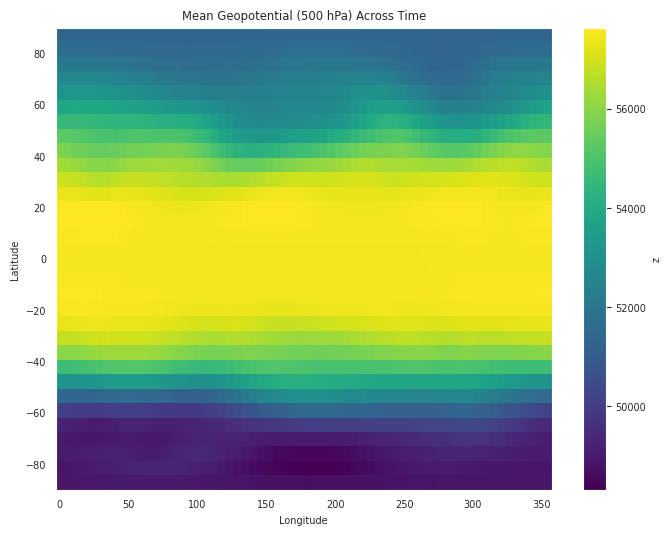

In [5]:
mean_z = data.z.mean(dim='time')
mean_z.plot(cmap='viridis')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean Geopotential (500 hPa) Across Time")
plt.show()

We can use periodogram to extract possible periodicity

We first analyse the worst point

Peak at frequency = 0.00011 cycles/hour (corresponding period = 8766.67 hrs = 365.28 days = 12.18 months), power = 1597528.12500 * 1e5
Peak at frequency = 0.00023 cycles/hour (corresponding period = 4383.33 hrs = 182.64 days = 6.09 months), power = 123799.27344 * 1e5
Peak at frequency = 0.00010 cycles/hour (corresponding period = 10520.00 hrs = 438.33 days = 14.61 months), power = 29591.04688 * 1e5
Peak at frequency = 0.00051 cycles/hour (corresponding period = 1972.50 hrs = 82.19 days = 2.74 months), power = 28796.62891 * 1e5
Peak at frequency = 0.00100 cycles/hour (corresponding period = 998.73 hrs = 41.61 days = 1.39 months), power = 27344.50977 * 1e5


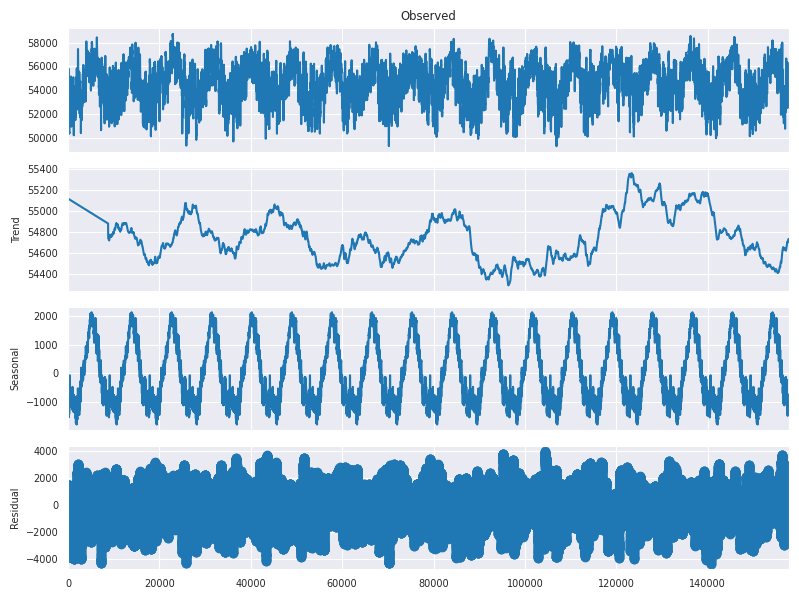

In [5]:
periods = freq_spectrum(point_worst, plot=False)
detrend_point_worst = seasonal_decompose(point_worst, period=periods, two_sided=False, extrapolate_trend='freq')
detrend_point_worst.plot()
plt.show()
#resid_point_worst = detrend_point_worst.resid
trend_point_worst = detrend_point_worst.trend
seasonal_point_worst = detrend_point_worst.seasonal + trend_point_worst.mean()
detrend_point_worst = point_worst.values - seasonal_point_worst

Peak at frequency = 0.00057 cycles/hour (corresponding period = 1752.00 hrs = 73.00 days = 2.43 months), power = 9171.38677 * 1e5
Peak at frequency = 0.00137 cycles/hour (corresponding period = 730.00 hrs = 30.42 days = 1.01 months), power = 8910.95358 * 1e5
Peak at frequency = 0.00011 cycles/hour (corresponding period = 8760.00 hrs = 365.00 days = 12.17 months), power = 7953.62988 * 1e5
Peak at frequency = 0.00308 cycles/hour (corresponding period = 324.44 hrs = 13.52 days = 0.45 months), power = 6052.03031 * 1e5
Peak at frequency = 0.00103 cycles/hour (corresponding period = 973.33 hrs = 40.56 days = 1.35 months), power = 5168.00264 * 1e5


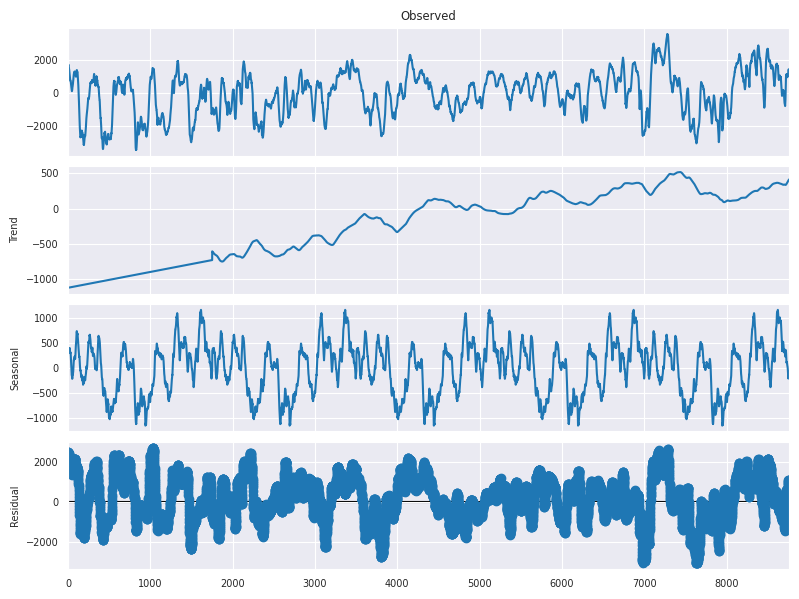

In [76]:
periods = freq_spectrum(detrend_point_worst[-8760:], plot=False)
detrend_point_worst2 = seasonal_decompose(detrend_point_worst[-8760:], period=periods, two_sided=False, extrapolate_trend='freq')
detrend_point_worst2.plot()
plt.show()
#resid_point_worst2 = detrend_point_worst2.resid
trend_point_worst2 = detrend_point_worst2.trend
seasonal_point_worst2 = detrend_point_worst2.seasonal + trend_point_worst2.mean()
detrend_point_worst2 = detrend_point_worst[-8760:] - seasonal_point_worst2

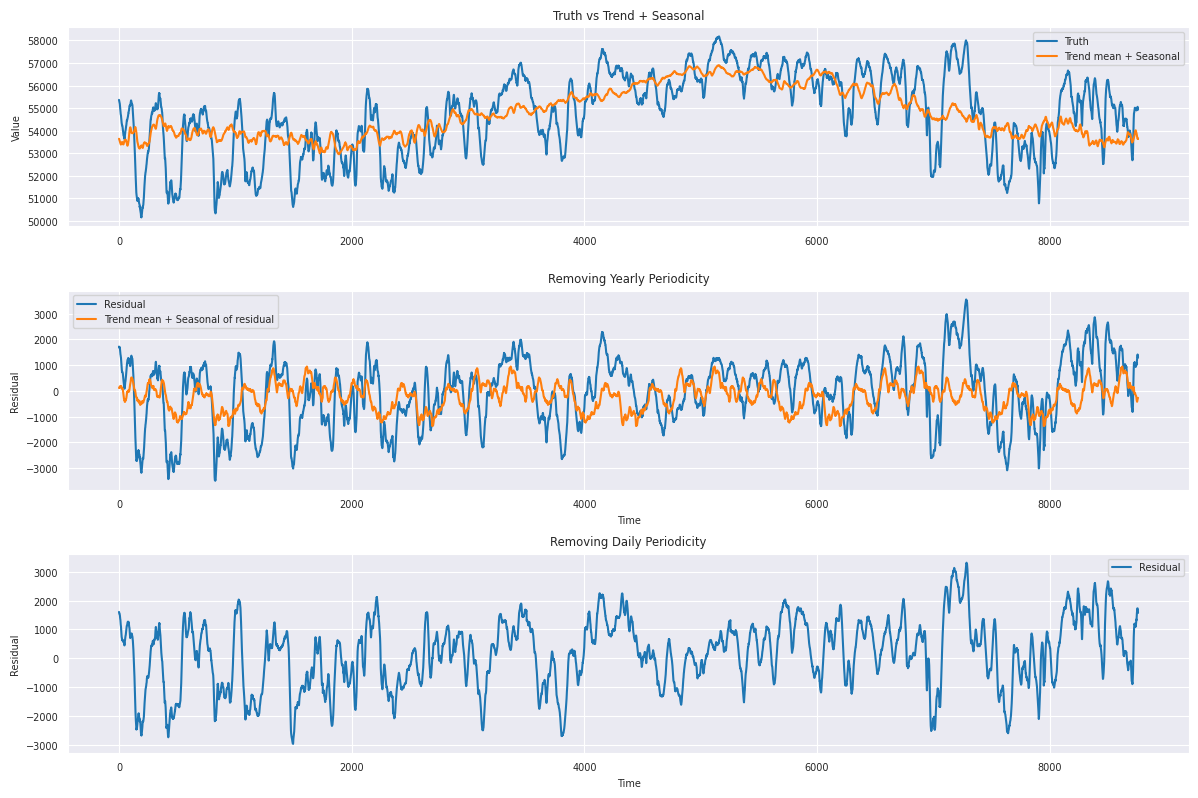

In [78]:
values = point_worst.values[-8760:]
seasonal = seasonal_point_worst[-8760:]
seasonal2 = seasonal_point_worst2[-8760:]

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(12, 8))

# Top subplot: Truth and Trend + Seasonal
ax1.plot(values, label='Truth')
ax1.plot(seasonal, label='Trend mean + Seasonal')
ax1.set_title('Truth vs Trend + Seasonal')
ax1.set_ylabel('Value')
ax1.legend(loc='best')

# Bottom subplot: Residuals (Truth - Seasonal)
residual = values - seasonal
ax2.plot(residual, label='Residual')
ax2.plot(seasonal2, label='Trend mean + Seasonal of residual')
ax2.set_title('Removing Yearly Periodicity')
ax2.set_xlabel('Time')
ax2.set_ylabel('Residual')
ax2.legend(loc='best')

# Bottom subplot: Residuals (Truth - Seasonal)
residual2 = residual - seasonal2
ax3.plot(residual2, label='Residual')
ax3.set_title('Removing Daily Periodicity')
ax3.set_xlabel('Time')
ax3.set_ylabel('Residual')
ax3.legend(loc='best')

plt.tight_layout()
plt.show()

Peak at frequency = 0.00002 cycles/hour (corresponding period = 43836.00 hrs = 1826.50 days = 60.88 months), power = 26605.71615 * 1e5
Peak at frequency = 0.00018 cycles/hour (corresponding period = 5479.50 hrs = 228.31 days = 7.61 months), power = 21811.41767 * 1e5
Peak at frequency = 0.00063 cycles/hour (corresponding period = 1594.04 hrs = 66.42 days = 2.21 months), power = 21380.80368 * 1e5
Peak at frequency = 0.00009 cycles/hour (corresponding period = 10959.00 hrs = 456.62 days = 15.22 months), power = 20376.23095 * 1e5
Peak at frequency = 0.00029 cycles/hour (corresponding period = 3506.88 hrs = 146.12 days = 4.87 months), power = 16334.69798 * 1e5


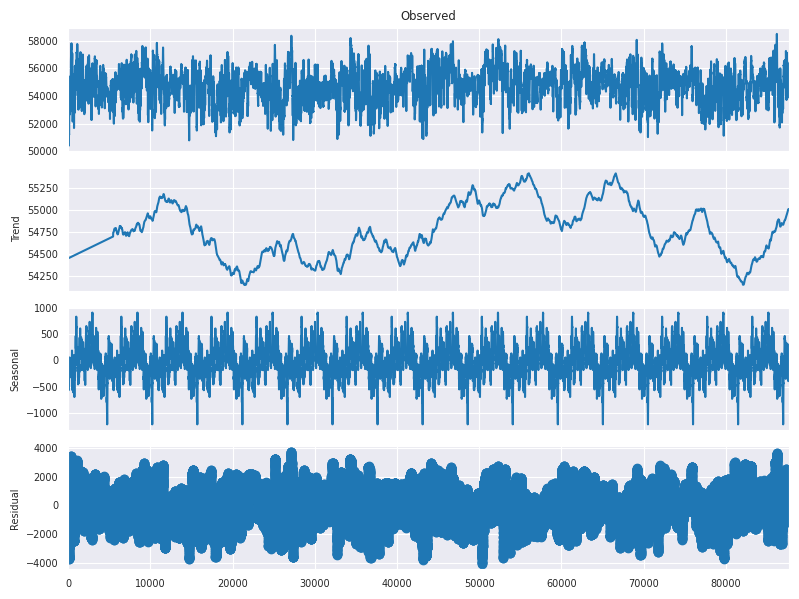

In [175]:
periods = freq_spectrum(detrend_point_worst2, plot=False)
detrend_point_worst3 = seasonal_decompose(detrend_point_worst2, period=periods, two_sided=False, extrapolate_trend='freq')
detrend_point_worst3.plot()
plt.show()
resid_point_worst3 = detrend_point_worst3.resid
trend_point_worst3 = detrend_point_worst3.trend
seasonal_point_worst3 = detrend_point_worst3.seasonal
detrend_point_worst3 = resid_point_worst3 + trend_point_worst3

Peak at frequency = 0.00002 cycles/hour (corresponding period = 43836.00 hrs = 1826.50 days = 60.88 months), power = 26600.63585 * 1e5
Peak at frequency = 0.00017 cycles/hour (corresponding period = 5844.80 hrs = 243.53 days = 8.12 months), power = 21456.72207 * 1e5
Peak at frequency = 0.00063 cycles/hour (corresponding period = 1594.04 hrs = 66.42 days = 2.21 months), power = 21369.85507 * 1e5
Peak at frequency = 0.00009 cycles/hour (corresponding period = 10959.00 hrs = 456.62 days = 15.22 months), power = 20365.20660 * 1e5
Peak at frequency = 0.00029 cycles/hour (corresponding period = 3506.88 hrs = 146.12 days = 4.87 months), power = 16339.73735 * 1e5


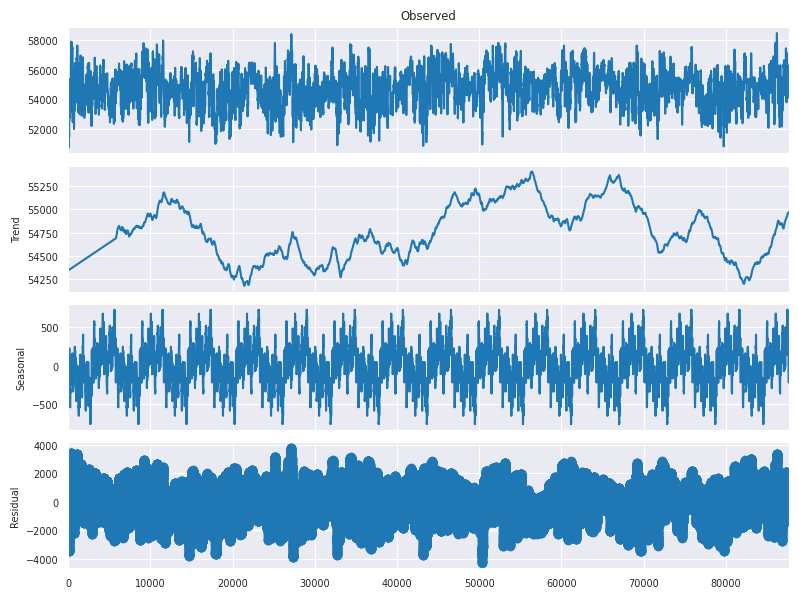

In [170]:
periods = freq_spectrum(detrend_point_worst3, plot=False)
detrend_point_worst4 = seasonal_decompose(detrend_point_worst3, period=periods, two_sided=False, extrapolate_trend='freq')
detrend_point_worst4.plot()
plt.show()
resid_point_worst4 = detrend_point_worst4.resid
trend_point_worst4 = detrend_point_worst4.trend
seasonal_point_worst4 = detrend_point_worst4.seasonal
detrend_point_worst4 = resid_point_worst4 + trend_point_worst4

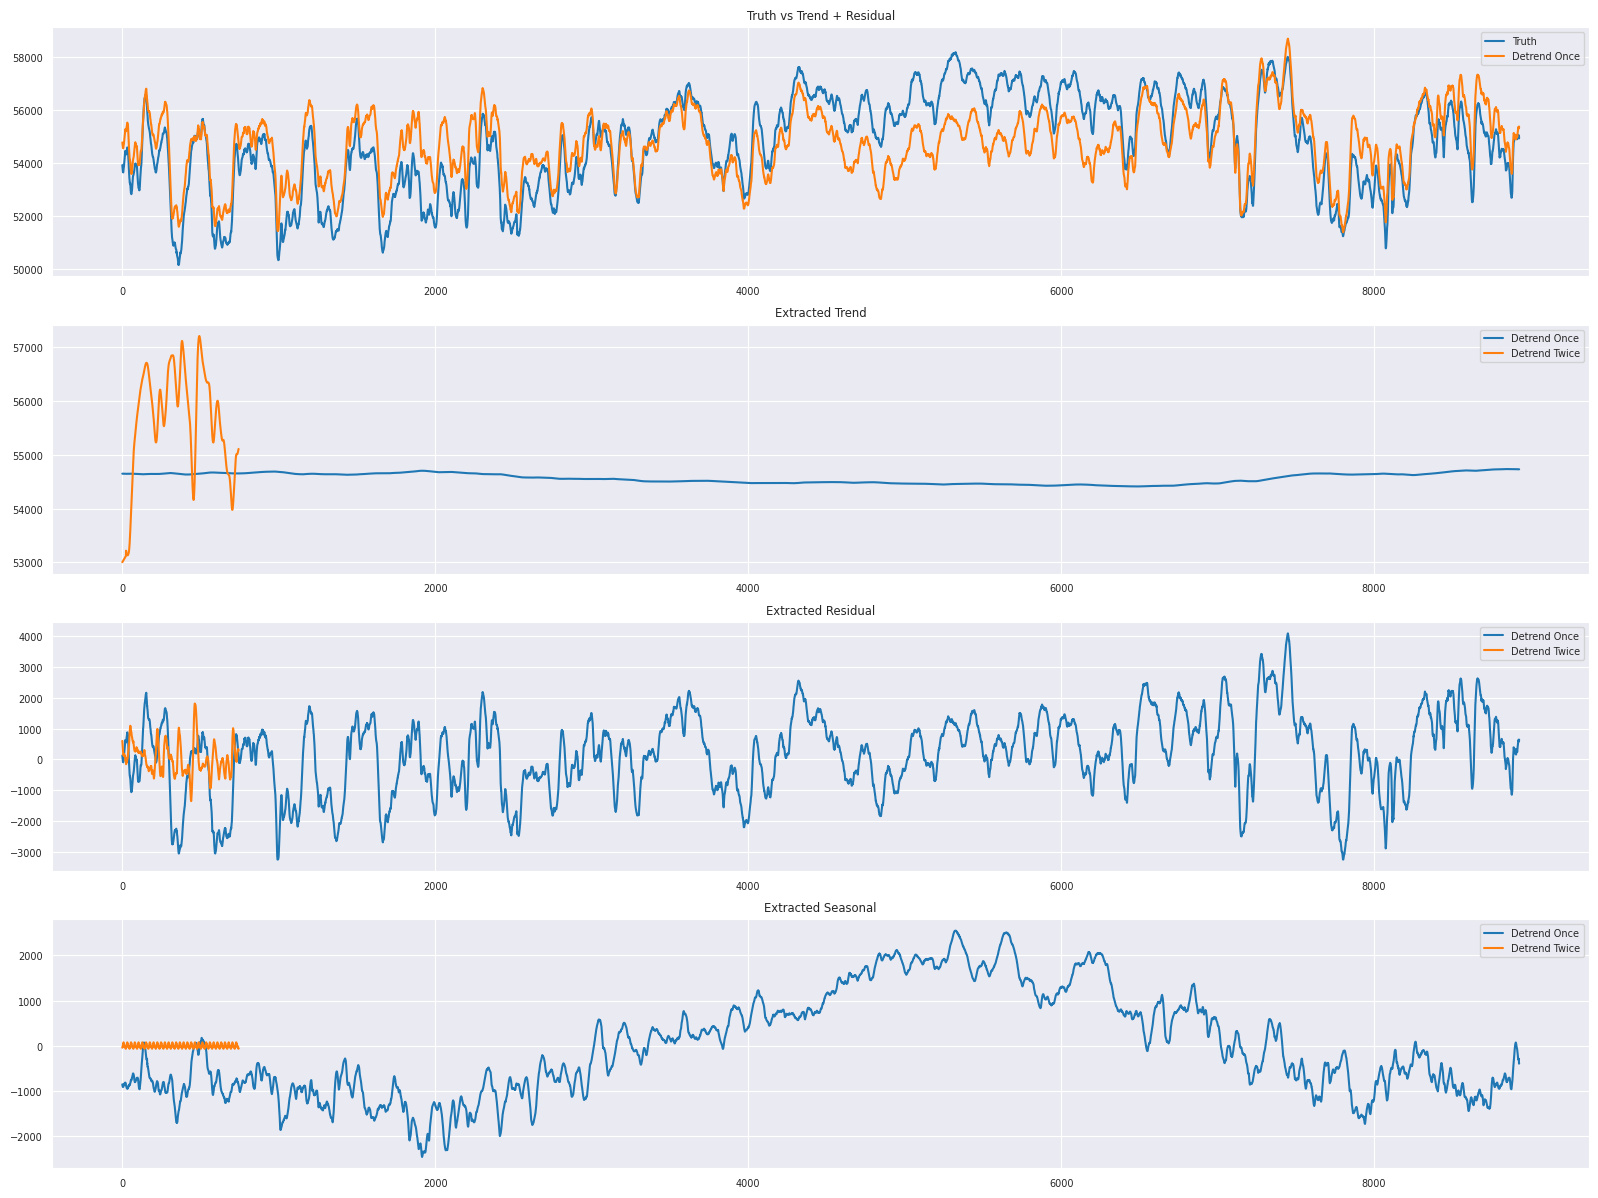

In [189]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(16, 12))
axs[0].plot(point_worst.values[-8928:], label="Truth")
axs[0].plot(detrend_point_worst[-8928:], label="Detrend Once")
#axs[0].plot(detrend_point_worst2[-8928:], label="Detrend Twice")
#axs[0].plot(detrend_point_worst3[-8928:], label="Detrend Thrice")
#axs[0].plot(detrend_point_worst4[-8928:], color='black', label="Final")
axs[0].set_title("Truth vs Trend + Residual")
axs[0].legend()

axs[1].plot(trend_point_worst[-8928:], label="Detrend Once")
axs[1].plot(trend_point_worst2[-8928:], label='Detrend Twice')
#axs[1].plot(trend_point_worst3[-8928:], label='Detrend Thrice')
#axs[1].plot(trend_point_worst4[-8928:], color='black', label="Final")
axs[1].set_title("Extracted Trend")
axs[1].legend()

axs[2].plot(resid_point_worst[-8928:], label="Detrend Once")
axs[2].plot(resid_point_worst2[-8928:], label='Detrend Twice')
#axs[2].plot(resid_point_worst3[-8928:], label='Detrend Thrice')
#axs[2].plot(resid_point_worst4[-8928:], color='black', label="Final")
axs[2].set_title("Extracted Residual")
axs[2].legend()

axs[3].plot(seasonal_point_worst[-8928:], label="Detrend Once")
axs[3].plot(seasonal_point_worst2[-8928:], label='Detrend Twice')
#axs[3].plot(seasonal_point_worst3[-8928:], label='Detrend Thrice')
#axs[3].plot(seasonal_point_worst4[-8928:], color='black', label="Final")
axs[3].set_title("Extracted Seasonal")
axs[3].legend()

fig.tight_layout()
plt.show()

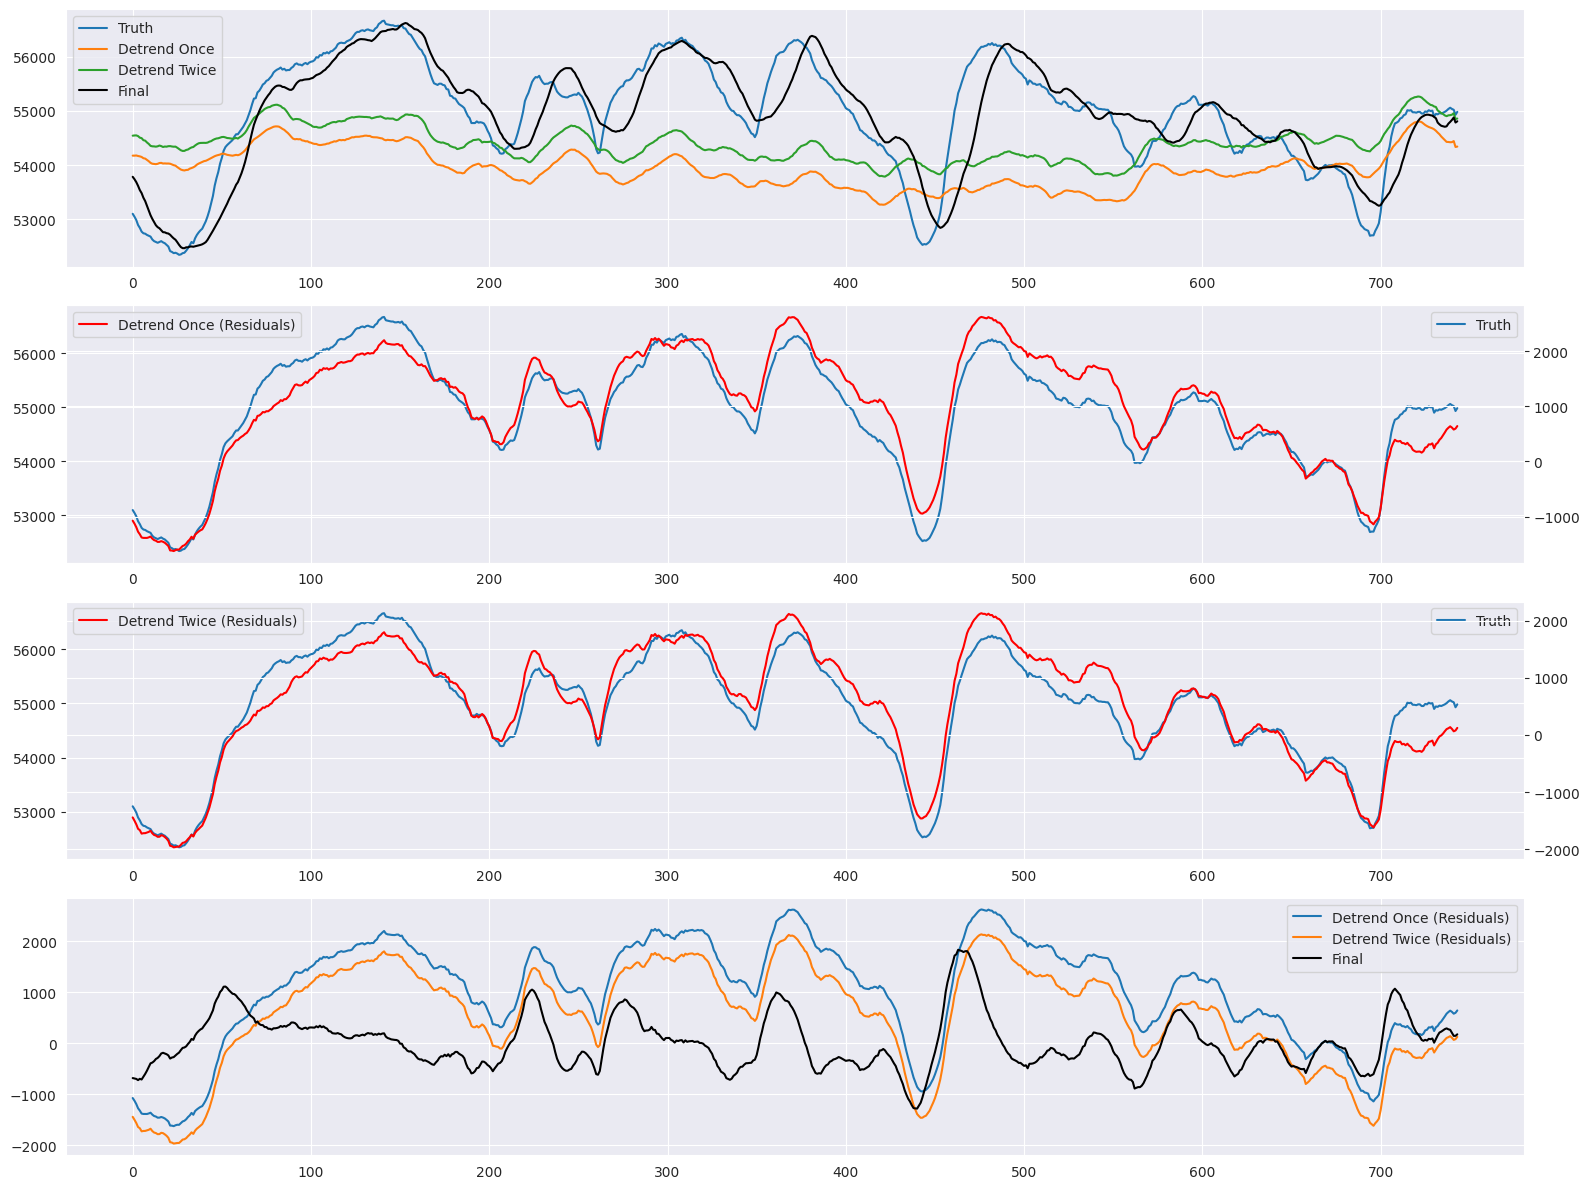

In [9]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(16, 12))
axs[0].plot(point_worst.values[-744:], label="Truth")
axs[0].plot(detrend_point_worst[-744:], label="Detrend Once")
axs[0].plot(detrend_point_worst2[-744:], label="Detrend Twice")
axs[0].plot(detrend_point_worst3[-744:], color='black', label="Final")
axs[0].legend()

axs[1].plot(point_worst.values[-744:], label="Truth")
ax1 = axs[1].twinx()
ax1.plot(resid_point_worst[-744:], color='red', label='Detrend Once (Residuals)')
ax1.legend(loc='upper left')
axs[1].legend()

axs[2].plot(point_worst.values[-744:], label="Truth")
ax2 = axs[2].twinx()
ax2.plot(resid_point_worst2[-744:], color='red', label='Detrend Twice (Residuals)')
ax2.legend(loc='upper left')
axs[2].legend()

axs[3].plot(resid_point_worst[-744:], label="Detrend Once (Residuals)")
axs[3].plot(resid_point_worst2[-744:], label='Detrend Twice (Residuals)')
axs[3].plot(resid_point_worst3[-744:], color='black', label="Final")
axs[3].legend()

fig.tight_layout()
plt.show()

[]

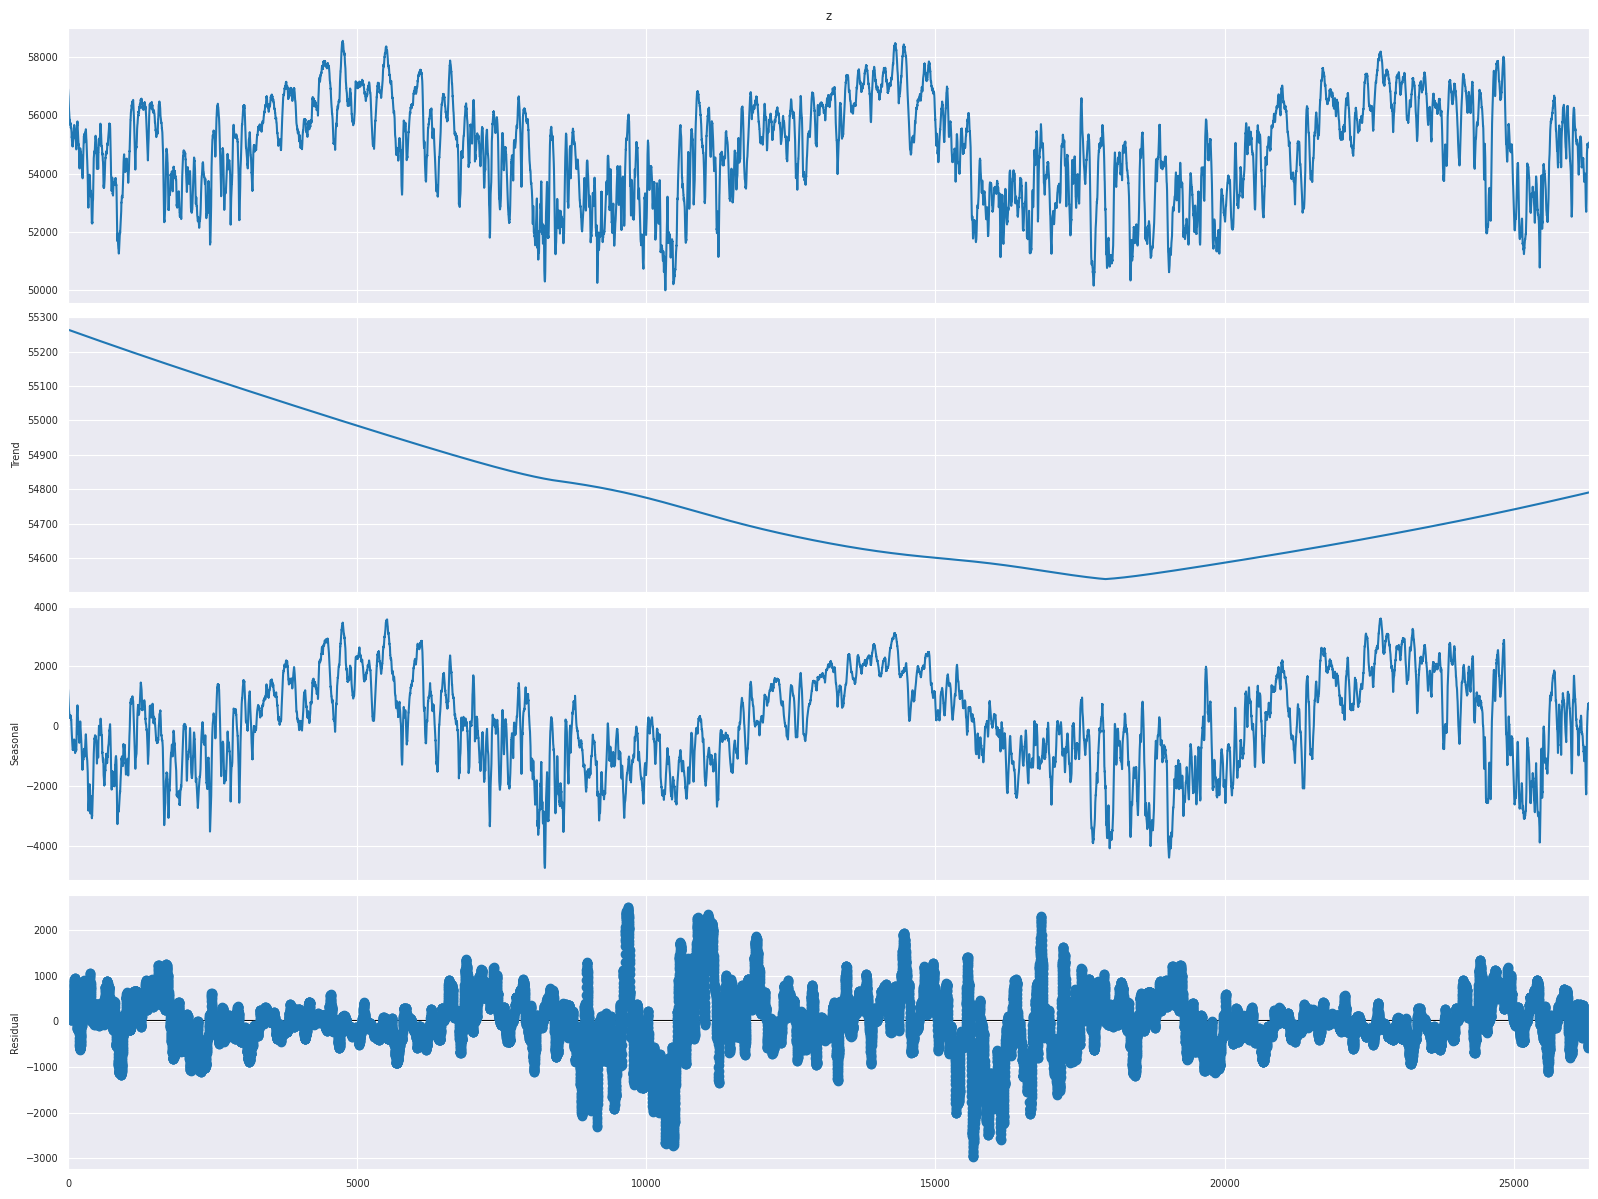

In [ ]:
detrend_point_worst_STL = STL(point_worst, period=8768)
residual_point_worst_STL = detrend_point_worst_STL.fit()
residual_point_worst_STL.plot()
plt.plot()

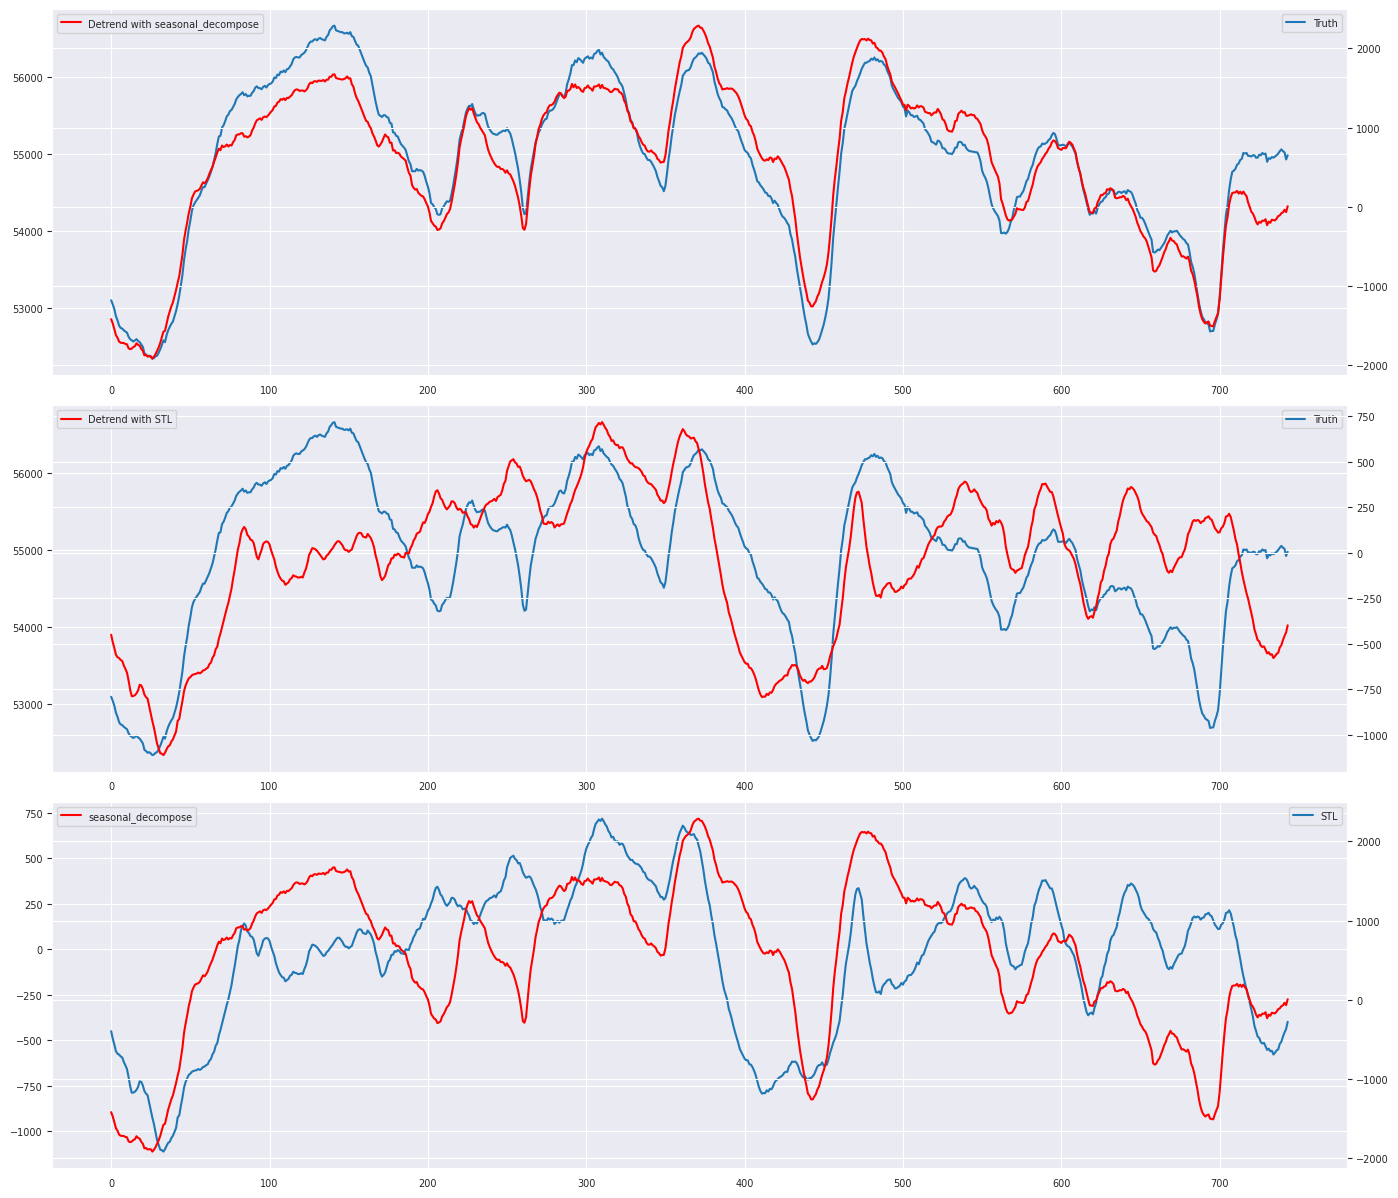

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(14, 12))
axs[0].plot(point_worst.values[-744:], label="Truth")
ax1 = axs[0].twinx()
ax1.plot(detrend_point_worst.resid[-744:], color='red', label='Detrend with seasonal_decompose')
ax1.legend(loc='upper left')
axs[0].legend()
axs[1].plot(point_worst.values[-744:], label="Truth")
ax2 = axs[1].twinx()
ax2.plot(residual_point_worst_STL.resid[25560:], color='red', label='Detrend with STL')
ax2.legend(loc='upper left')
axs[1].legend()
axs[2].plot(residual_point_worst_STL.resid[25560:], label="STL")
ax3 = axs[2].twinx()
ax3.plot(detrend_point_worst.resid[-744:], color='red', label='seasonal_decompose')
ax3.legend(loc='upper left')
axs[2].legend()
fig.tight_layout()
plt.show()

## Point Best on z500

Peak at frequency = 0.00011 cycles/hour (corresponding period = 8766.55 hrs = 365.27 days = 12.18 months), power = 892865728.00000
Peak at frequency = 0.08333 cycles/hour (corresponding period = 12.00 hrs = 0.50 days = 0.02 months), power = 402739904.00000
Peak at frequency = 0.00001 cycles/hour (corresponding period = 96432.00 hrs = 4018.00 days = 133.93 months), power = 255784992.00000
Peak at frequency = 0.00034 cycles/hour (corresponding period = 2922.18 hrs = 121.76 days = 4.06 months), power = 53394544.00000
Peak at frequency = 0.00023 cycles/hour (corresponding period = 4383.27 hrs = 182.64 days = 6.09 months), power = 43334524.00000
Peak at frequency = 0.00009 cycles/hour (corresponding period = 10714.67 hrs = 446.44 days = 14.88 months), power = 42343688.00000


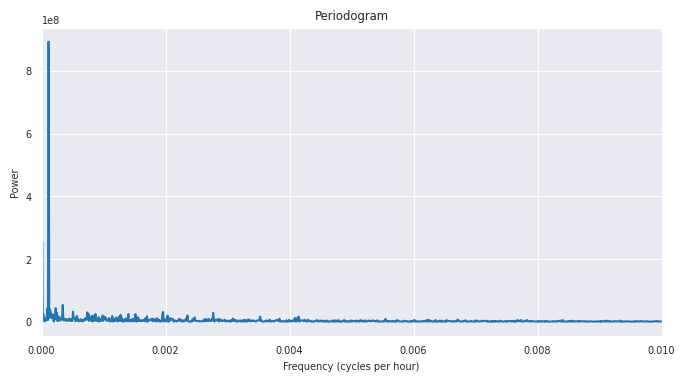

In [ ]:
fs = 1.0  # Sampling frequency: 1 sample per hour
freqs, power = periodogram(point_best.values, fs=fs)
peaks, properties = find_peaks(power, height=100, distance=1)

# Sort the peaks by their power (descending order), then pick three peaks
sorted_peak_indices = np.argsort(power[peaks])[::-1]
top5_indices = sorted_peak_indices[:6]
top5_peaks = peaks[top5_indices]

peak_freqs = freqs[top5_peaks]
peak_powers = power[top5_peaks]

for f, p in zip(peak_freqs, peak_powers):
    print(f"Peak at frequency = {f:.5f} cycles/hour (corresponding period = {1/f:.2f} hrs = {1/f/24:.2f} days = {1/f/(24*30):.2f} months), power = {p:.5f}")


plt.figure(figsize=(8, 4))
plt.plot(freqs, power)
plt.xlim(0, 0.01)
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Power')
plt.title('Periodogram')
plt.show()

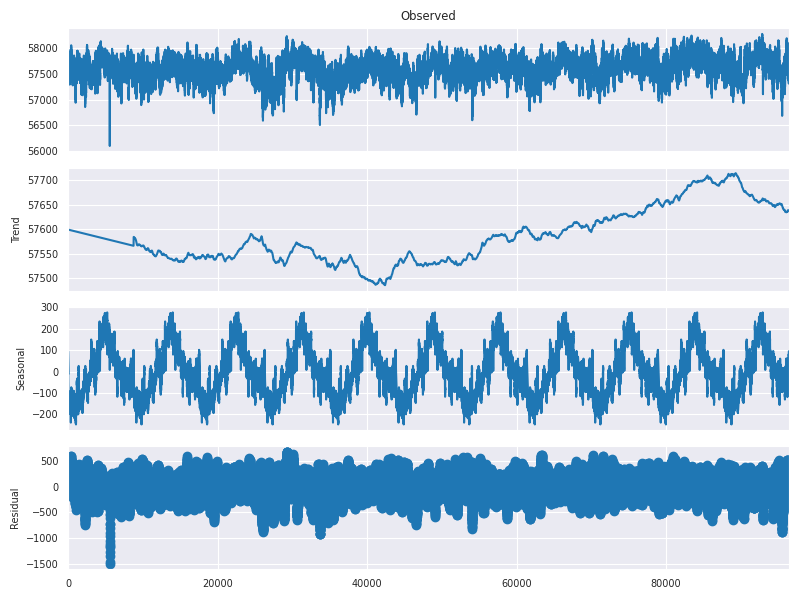

In [ ]:
detrend_point_best = seasonal_decompose(point_best.values, period=8767, two_sided=False, extrapolate_trend='freq')
detrend_point_best.plot()
plt.show()

resid_point_best = detrend_point_best.resid
detrend_point_best = detrend_point_best.trend+detrend_point_best.seasonal

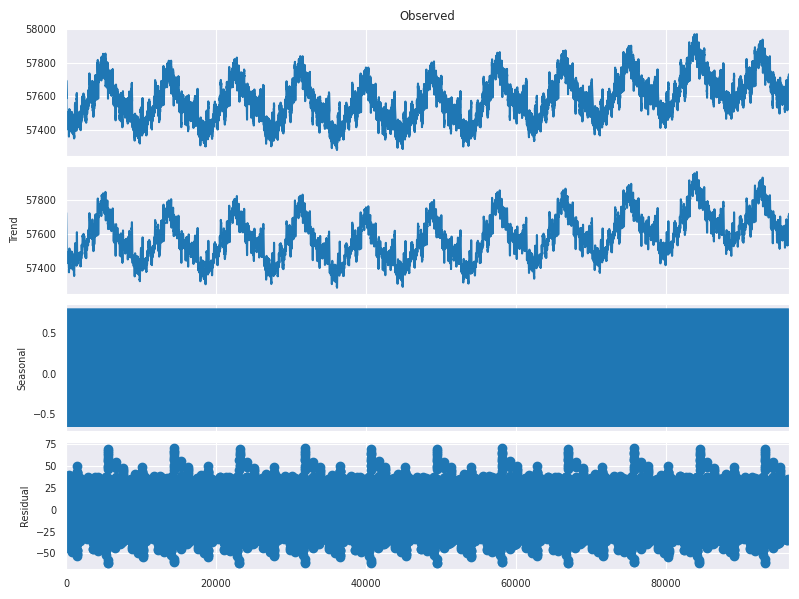

In [ ]:
detrend_point_best2 = seasonal_decompose(detrend_point_best, period=12, two_sided=False, extrapolate_trend='freq')
detrend_point_best2.plot()
plt.show()

resid_point_best2 = detrend_point_best2.resid
detrend_point_best2 = detrend_point_best2.trend+detrend_point_best2.seasonal

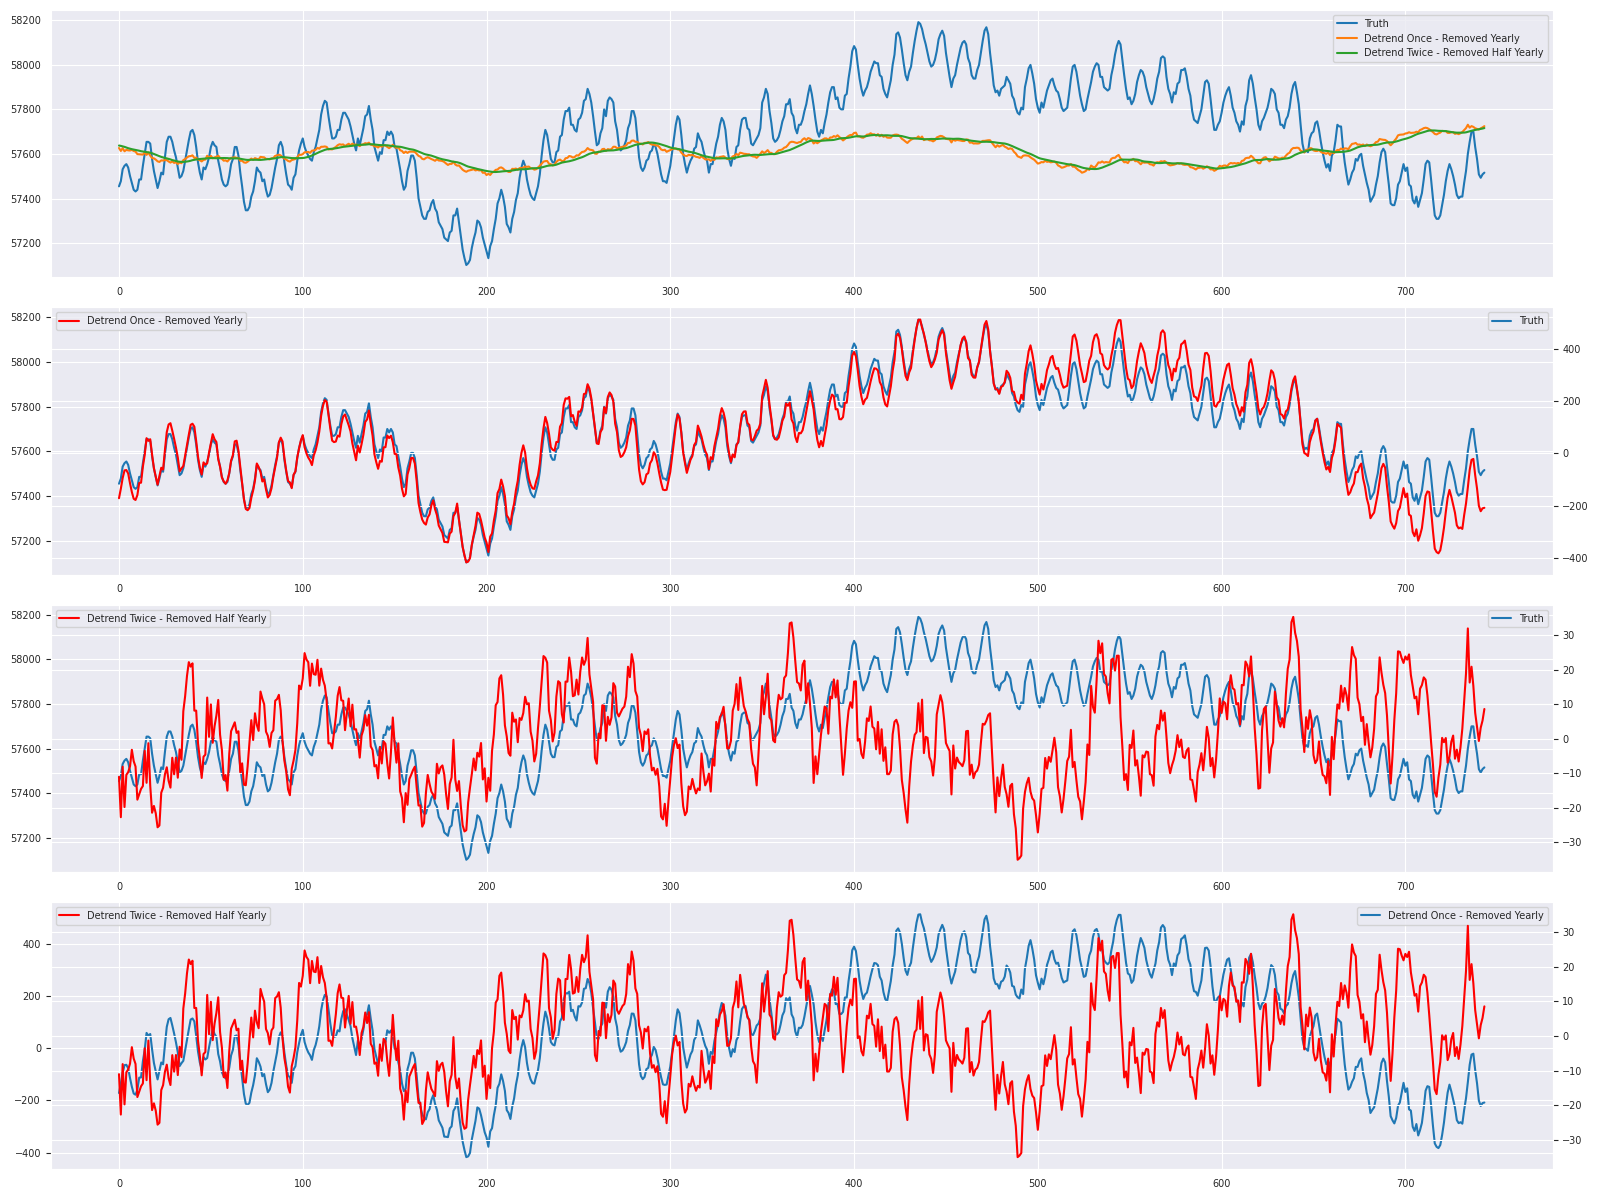

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(16, 12))
axs[0].plot(point_best.values[-744:], label="Truth")
axs[0].plot(detrend_point_best[-744:], label="Detrend Once - Removed Yearly")
axs[0].plot(detrend_point_best2[-744:], label="Detrend Twice - Removed Half Yearly")
axs[0].legend()

axs[1].plot(point_best.values[-744:], label="Truth")
ax1 = axs[1].twinx()
ax1.plot(resid_point_best[-744:], color='red', label='Detrend Once - Removed Yearly')
ax1.legend(loc='upper left')
axs[1].legend()

axs[2].plot(point_best.values[-744:], label="Truth")
ax2 = axs[2].twinx()
ax2.plot(resid_point_best2[-744:], color='red', label='Detrend Twice - Removed Half Yearly')
ax2.legend(loc='upper left')
axs[2].legend()

axs[3].plot(resid_point_best[-744:], label="Detrend Once - Removed Yearly")
ax3 = axs[3].twinx()
ax3.plot(resid_point_best2[-744:], color='red', label='Detrend Twice - Removed Half Yearly')
ax3.legend(loc='upper left')
axs[3].legend()

fig.tight_layout()
plt.show()

In [ ]:
MSTL_detrend_point_best = MSTL(point_best, periods=[8767, 12]).fit()
MSTL_detrend_point_best.plot()
plt.show()

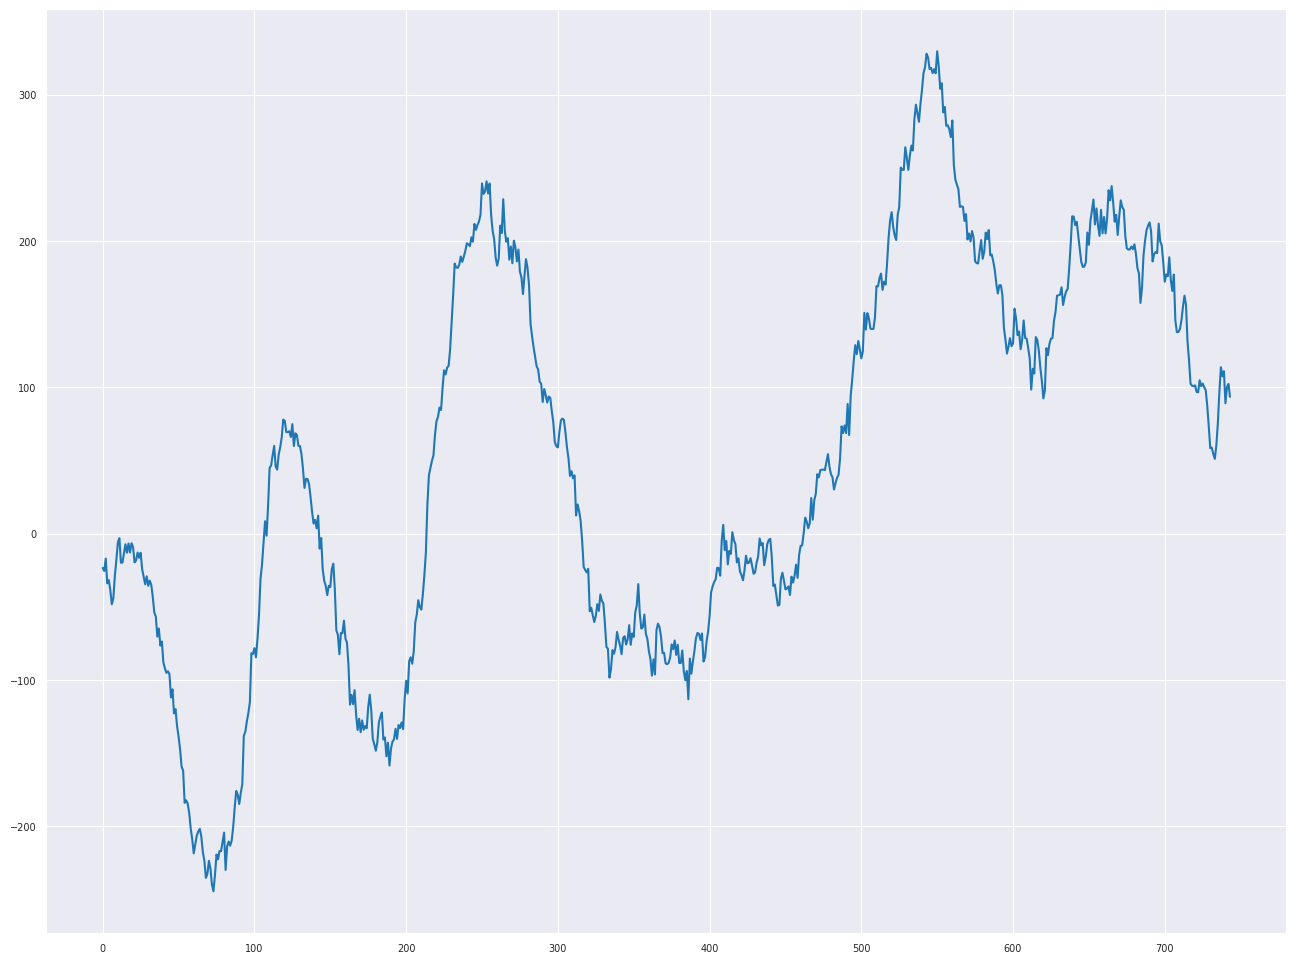

In [ ]:
# Residuals during 2017/12
plt.plot(MSTL_detrend_point_best.resid[-744:])
plt.show()